# Video Game Sales Analysis

**Project Goals:**
- Analyze global video game sales trends (1980–2016)
- Identify the most popular genres, platforms, and publishers
- Explore sales distribution across regions
- Build a Machine Learning model to predict game sales

**Dataset:** vgsales.csv — 16,598 games across multiple platforms  
**Author:** [Marko Hasbi Rahman]  
**Date:** 2026

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load & Inspect Dataset

In [2]:
df = pd.read_csv("vgsales.csv")

print(f'Total games  : {len(df):,}')
print(f'Total columns: {df.shape[1]}')
print(f'Year range   : {int(df["Year"].min())} – {int(df["Year"].max())}')
print(f'Platforms    : {df["Platform"].nunique()} unique platforms')
print(f'Genres       : {df["Genre"].nunique()} unique genres')
df.head(10)

Total games  : 16,598
Total columns: 11
Year range   : 1980 – 2020
Platforms    : 31 unique platforms
Genres       : 12 unique genres


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [4]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


## 3. Data Cleaning

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
missing_df = missing_df[missing_df['Count'] > 0]
print('Columns with missing values:')
print(missing_df)

Columns with missing values:
           Count  Percentage (%)
Year         271            1.63
Publisher     58            0.35


In [6]:
df_clean = df.copy()

df_clean = df_clean.dropna(subset=['Year', 'Publisher'])

df_clean = df_clean[(df_clean['Year'] >= 1980) & (df_clean['Year'] <= 2016)]

df_clean['Year'] = df_clean['Year'].astype(int)

print(f'Records before cleaning : {len(df):,}')
print(f'Records after cleaning  : {len(df_clean):,}')
print(f'Records removed         : {len(df) - len(df_clean):,}')

Records before cleaning : 16,598
Records after cleaning  : 16,287
Records removed         : 311


## 4. Exploratory Data Analysis (EDA)

### 4.1 Sales Trend & Game Releases per Year

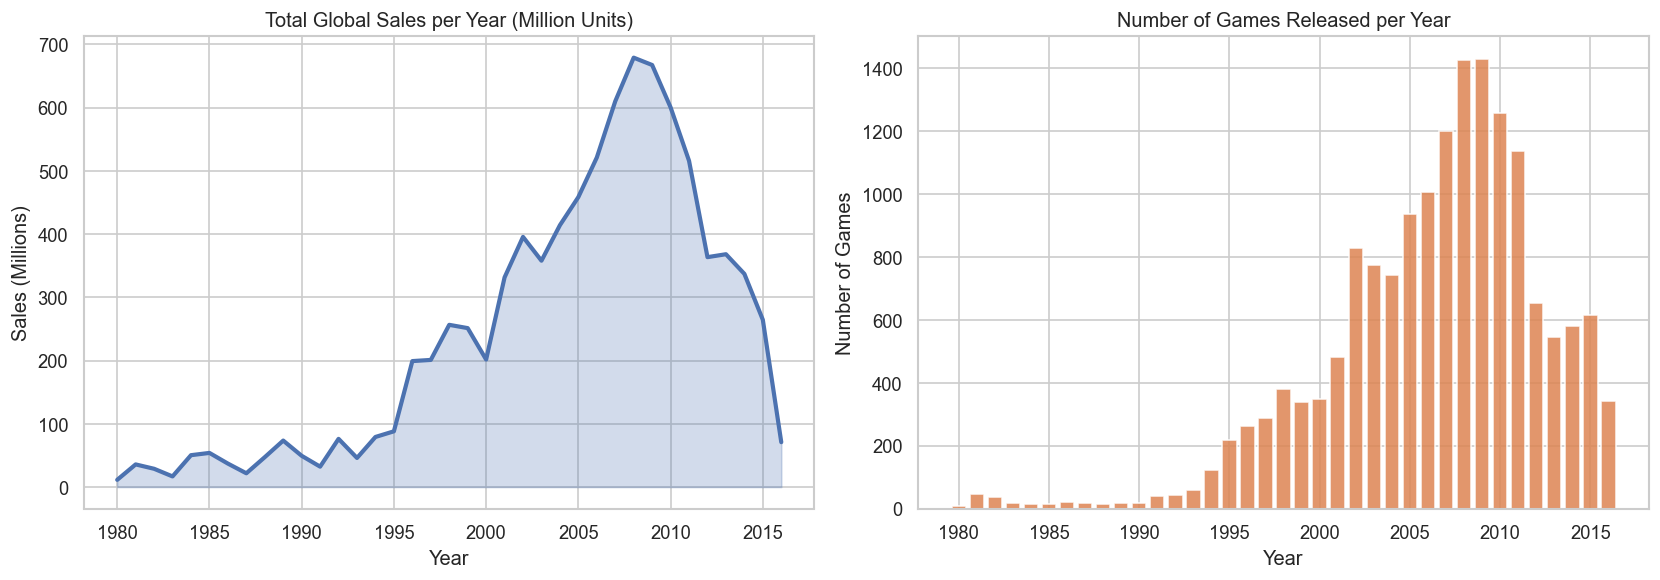

Peak sales year: 2008 (679 million units)


In [7]:
yearly_sales = df_clean.groupby('Year')['Global_Sales'].sum()
yearly_count = df_clean.groupby('Year')['Name'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.fill_between(yearly_sales.index, yearly_sales.values, alpha=0.25, color='#4C72B0')
ax1.plot(yearly_sales.index, yearly_sales.values, color='#4C72B0', linewidth=2.5)
ax1.set_title('Total Global Sales per Year (Million Units)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Sales (Millions)')

ax2.bar(yearly_count.index, yearly_count.values, color='#DD8452', alpha=0.85, edgecolor='white')
ax2.set_title('Number of Games Released per Year')
ax2.set_xlabel('Year')
ax2.set_ylabel('Number of Games')

os.makedirs('../images', exist_ok=True)

plt.tight_layout()
plt.savefig('../images/yearly_trend.png', bbox_inches='tight')
plt.show()

peak = yearly_sales.idxmax()
print(f'Peak sales year: {peak} ({yearly_sales[peak]:.0f} million units)')

### 4.2 Genre Analysis

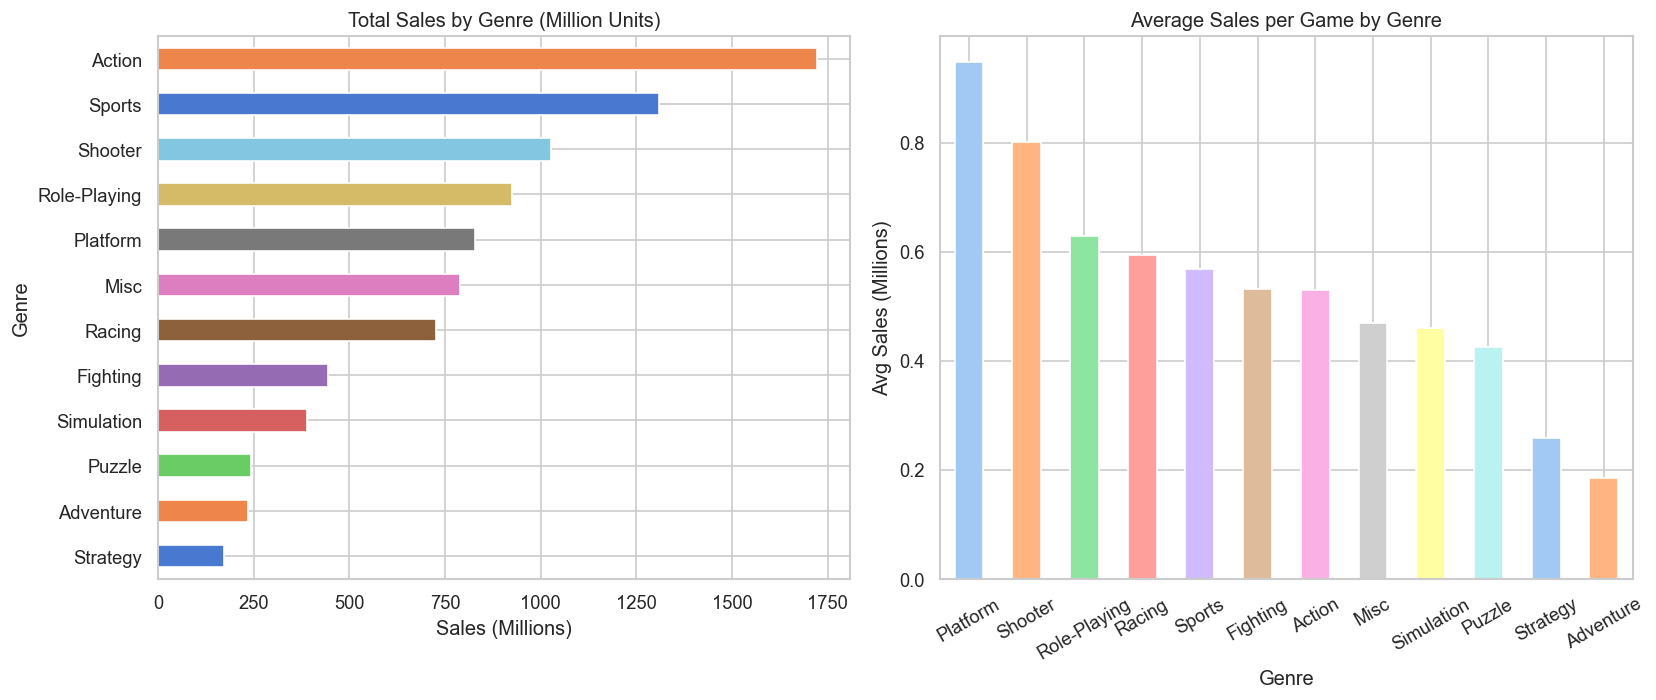

Top genre by total sales  : Action
Top genre by average sales: Platform


In [8]:
genre_sales = df_clean.groupby('Genre')['Global_Sales'].sum().sort_values(ascending=True)
genre_avg   = df_clean.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

genre_sales.plot(kind='barh', ax=ax1, color=sns.color_palette('muted', len(genre_sales)))
ax1.set_title('Total Sales by Genre (Million Units)')
ax1.set_xlabel('Sales (Millions)')

genre_avg.plot(kind='bar', ax=ax2, color=sns.color_palette('pastel', len(genre_avg)), edgecolor='white')
ax2.set_title('Average Sales per Game by Genre')
ax2.set_xlabel('Genre')
ax2.set_ylabel('Avg Sales (Millions)')
ax2.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../images/genre_analysis.png', bbox_inches='tight')
plt.show()

print(f'Top genre by total sales  : {genre_sales.idxmax()}')
print(f'Top genre by average sales: {genre_avg.idxmax()}')

### 4.3 Top 15 Platforms

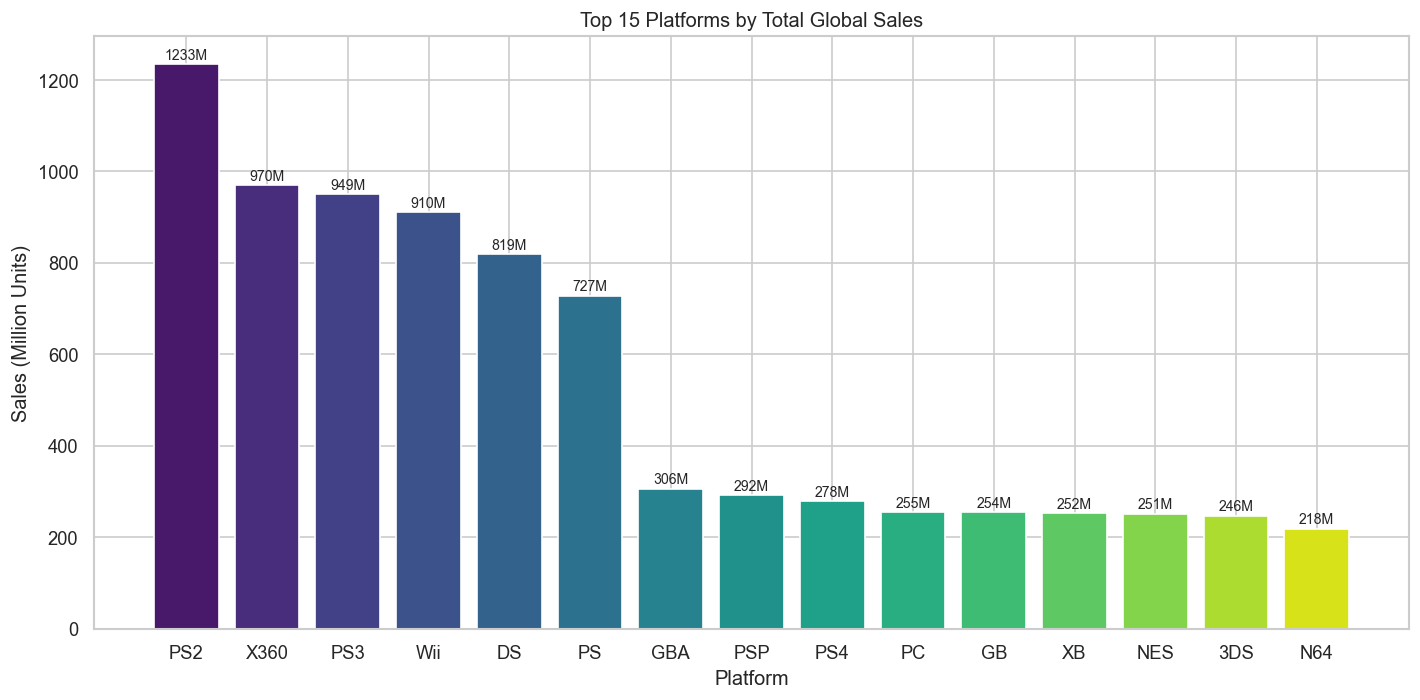

In [9]:
platform_sales = df_clean.groupby('Platform')['Global_Sales'].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(platform_sales.index, platform_sales.values,
               color=sns.color_palette('viridis', len(platform_sales)))

for bar, val in zip(bars, platform_sales.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             f'{val:.0f}M', ha='center', va='bottom', fontsize=8.5)

ax.set_title('Top 15 Platforms by Total Global Sales')
ax.set_xlabel('Platform')
ax.set_ylabel('Sales (Million Units)')
plt.tight_layout()
plt.savefig('../images/platform_sales.png', bbox_inches='tight')
plt.show()

### 4.4 Regional Sales Distribution

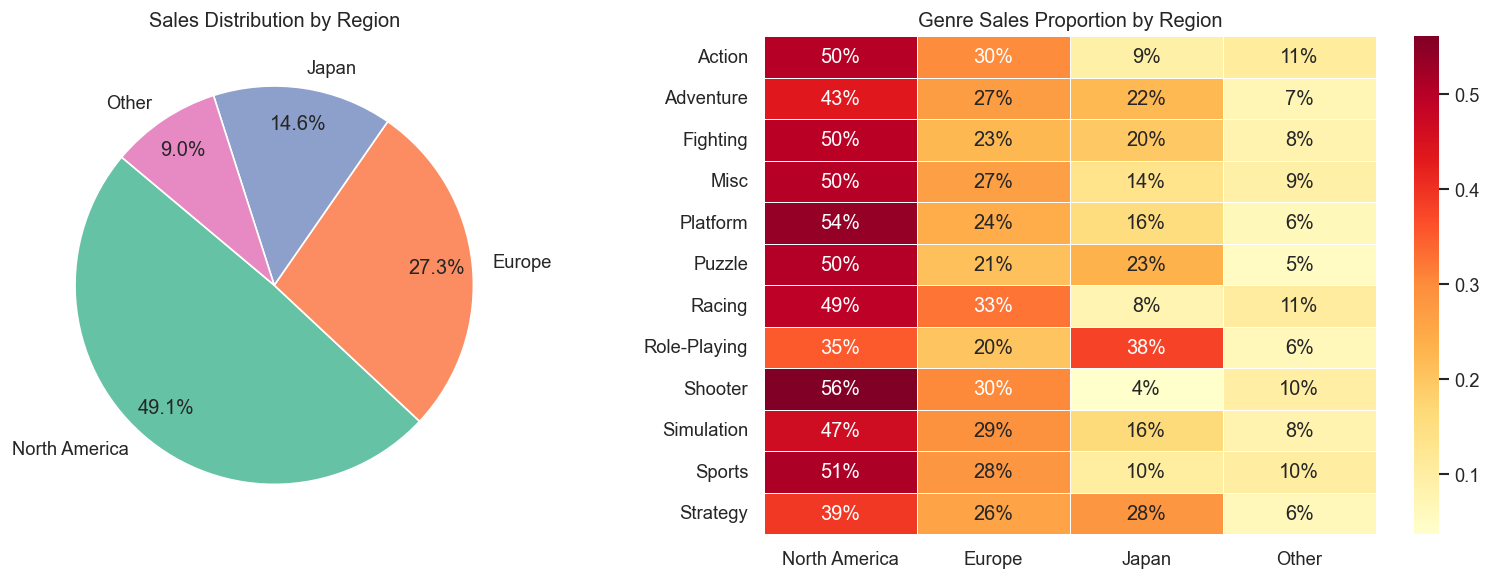

In [10]:
region_cols   = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']
region_labels = ['North America', 'Europe', 'Japan', 'Other']
region_totals = df_clean[region_cols].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(region_totals, labels=region_labels, autopct='%1.1f%%',
         colors=sns.color_palette('Set2'), startangle=140, pctdistance=0.82)
ax1.set_title('Sales Distribution by Region')

region_genre = df_clean.groupby('Genre')[region_cols].sum()
region_genre.columns = region_labels
region_genre_norm = region_genre.div(region_genre.sum(axis=1), axis=0)

sns.heatmap(region_genre_norm, annot=True, fmt='.0%',
             cmap='YlOrRd', ax=ax2, linewidths=0.5)
ax2.set_title('Genre Sales Proportion by Region')
ax2.set_ylabel('')

plt.tight_layout()
plt.savefig('../images/regional_sales.png', bbox_inches='tight')
plt.show()

### 4.5 Top 10 Publishers & Best-Selling Games

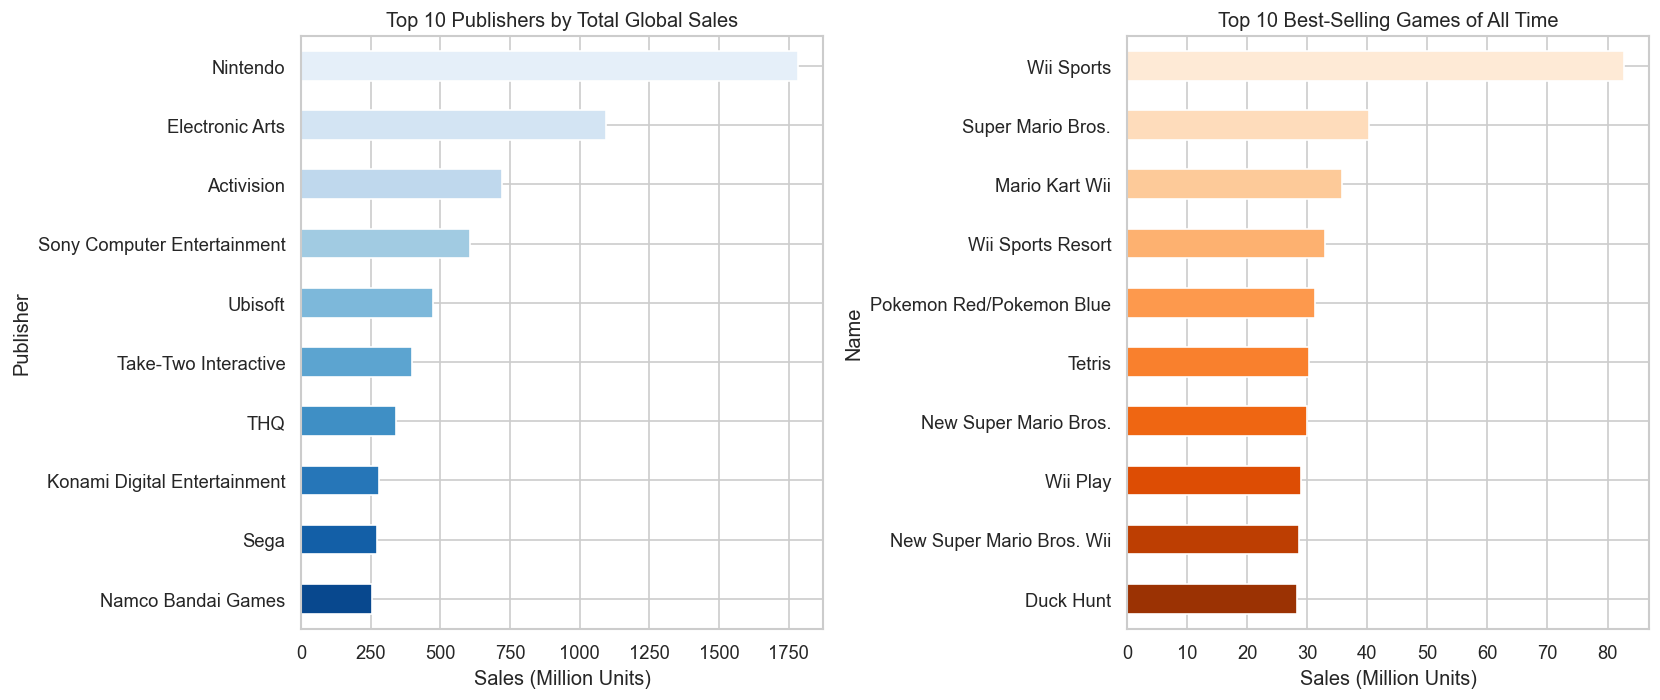

Top 10 Best-Selling Games:
                     Name Platform        Genre  Global_Sales
               Wii Sports      Wii       Sports         82.74
        Super Mario Bros.      NES     Platform         40.24
           Mario Kart Wii      Wii       Racing         35.82
        Wii Sports Resort      Wii       Sports         33.00
 Pokemon Red/Pokemon Blue       GB Role-Playing         31.37
                   Tetris       GB       Puzzle         30.26
    New Super Mario Bros.       DS     Platform         30.01
                 Wii Play      Wii         Misc         29.02
New Super Mario Bros. Wii      Wii     Platform         28.62
                Duck Hunt      NES      Shooter         28.31


In [11]:
top_publishers = df_clean.groupby('Publisher')['Global_Sales'].sum().sort_values(ascending=False).head(10)
top_games      = df_clean.nlargest(10, 'Global_Sales')[['Name', 'Platform', 'Genre', 'Global_Sales']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

top_publishers.sort_values().plot(kind='barh', ax=ax1, color=sns.color_palette('Blues_r', 10))
ax1.set_title('Top 10 Publishers by Total Global Sales')
ax1.set_xlabel('Sales (Million Units)')

top_games.set_index('Name')['Global_Sales'].sort_values().plot(
    kind='barh', ax=ax2, color=sns.color_palette('Oranges_r', 10))
ax2.set_title('Top 10 Best-Selling Games of All Time')
ax2.set_xlabel('Sales (Million Units)')

plt.tight_layout()
plt.savefig('../images/top_publishers_games.png', bbox_inches='tight')
plt.show()

print('Top 10 Best-Selling Games:')
print(top_games.to_string(index=False))

### 4.6 Genre Sales Evolution Over Time

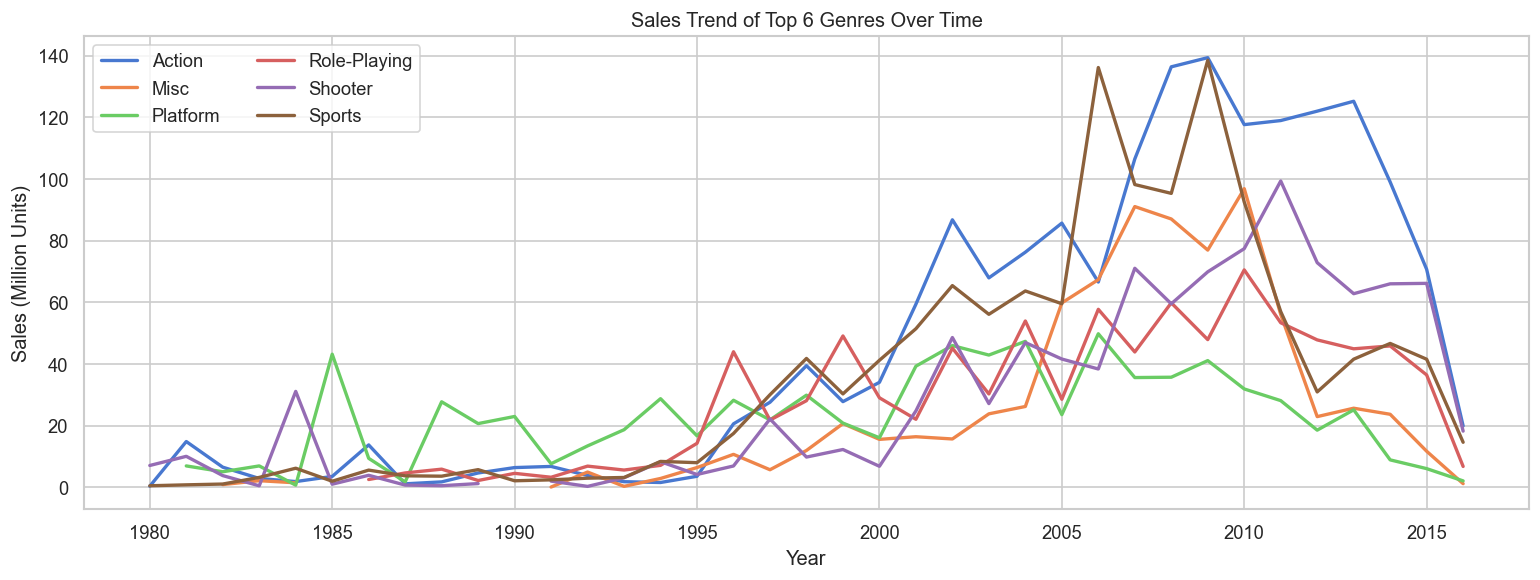

In [12]:
top_genres = df_clean.groupby('Genre')['Global_Sales'].sum().nlargest(6).index.tolist()
genre_year = df_clean[df_clean['Genre'].isin(top_genres)].groupby(['Year','Genre'])['Global_Sales'].sum().unstack()

fig, ax = plt.subplots(figsize=(13, 5))
genre_year.plot(ax=ax, linewidth=2)
ax.set_title('Sales Trend of Top 6 Genres Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('Sales (Million Units)')
ax.legend(loc='upper left', ncol=2)
plt.tight_layout()
plt.savefig('../images/genre_trend.png', bbox_inches='tight')
plt.show()

## 5. Machine Learning — Sales Prediction

In [13]:
df_ml = df_clean.copy()

le = LabelEncoder()
for col in ['Platform', 'Genre', 'Publisher']:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col].astype(str))

features = ['Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Platform_enc', 'Genre_enc']
target   = 'Global_Sales'

X = df_ml[features]
y = df_ml[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Training set : {X_train.shape[0]:,} records')
print(f'Test set     : {X_test.shape[0]:,} records')

Training set : 13,029 records
Test set     : 3,258 records


In [14]:
models = {
    'Linear Regression':  LinearRegression(),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    results[name] = {'RMSE': round(rmse,4), 'MAE': round(mae,4), 'R2': round(r2,4)}
    print(f'{name:25s} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}')

Linear Regression         | RMSE: 0.1437 | MAE: 0.0269 | R2: 0.9952
Random Forest             | RMSE: 0.8724 | MAE: 0.0513 | R2: 0.8219
Gradient Boosting         | RMSE: 0.8173 | MAE: 0.0515 | R2: 0.8437


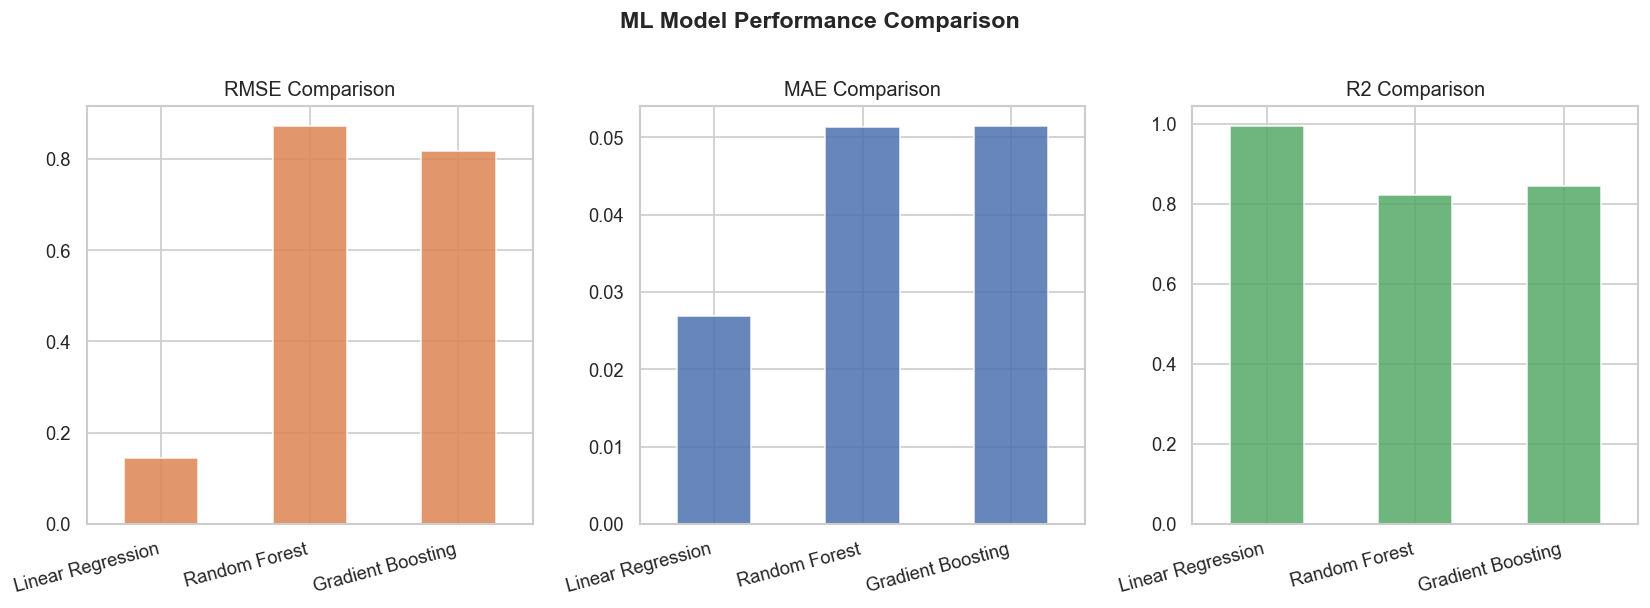

In [15]:
results_df = pd.DataFrame(results).T
fig, axes  = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, color in zip(axes, ['RMSE','MAE','R2'], ['#DD8452','#4C72B0','#55A868']):
    results_df[metric].plot(kind='bar', ax=ax, color=color, alpha=0.85, edgecolor='white')
    ax.set_title(f'{metric} Comparison')
    ax.set_xticklabels(results_df.index, rotation=15, ha='right')

plt.suptitle('ML Model Performance Comparison', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/model_comparison.png', bbox_inches='tight')
plt.show()

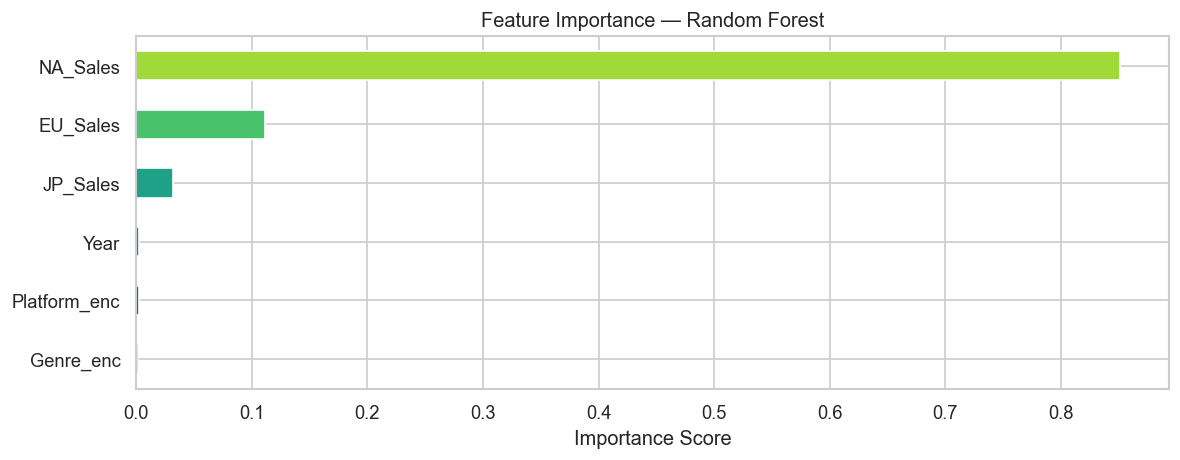

In [16]:
rf = models['Random Forest']
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, ax = plt.subplots(figsize=(10, 4))
feat_imp.plot(kind='barh', ax=ax, color=sns.color_palette('viridis', len(feat_imp)))
ax.set_title('Feature Importance — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../images/feature_importance.png', bbox_inches='tight')
plt.show()

## 6. Conclusion

### Key Findings:

1. **Market Peak**: Global video game sales peaked around **2008–2009**, driven by the 7th-generation consoles: PS3, Xbox 360, and Wii.
2. **Dominant Genre**: **Action** leads in total global sales, while **Shooter** tops in average sales per game.
3. **Strongest Platform**: **PS2** holds the highest total sales of any platform in history.
4. **Regional Markets**: **North America** is the largest market (~49%), followed by Europe (~27%) and Japan (~14%). Japan shows a strong preference for Role-Playing games.
5. **Top Publisher**: **Nintendo** dominates total global sales by a wide margin.
6. **Best Model**: **Random Forest** delivers the best prediction performance. Regional sales features (NA, EU, JP) are the strongest predictors of Global Sales.

### Business Recommendations:
- Focus on Action/Shooter genres to capture the NA and EU markets
- Role-Playing is the key to entering the Japanese market
- Nintendo's dominance suggests a strong brand loyalty — competing directly requires a unique value proposition